Подключение библиотек

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Загрузка и просмотр данных

In [ ]:
df = pd.read_excel('FPS_lecture_df_0_height-weignt.xlsx')
df.head()

,ID,Gender,Height,Weight
0,10001,Male,174.782639,78.652188
1,10002,Female,165.183571,74.332607
2,10003,Male,181.542046,81.693920
3,10004,Female,167.845912,75.530661
4,10005,Female,160.475255,72.213865


Формирование выборок по полу

In [ ]:
# Формирование выборок
df_1 = df[df['Gender'] == 'Male']
df_2 = df[df['Gender'] == 'Female']

print('Выборкки имеют одинаковую длинну: ', len(df_1) == len(df_2))

Выборкки имеют одинаковую длинну:  True


Визуализация доверительных интервалов

<ipython-input-6-60ed37333082>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_1['Weight'], 50)
<ipython-input-6-60ed37333082>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2['Weight'], 50)


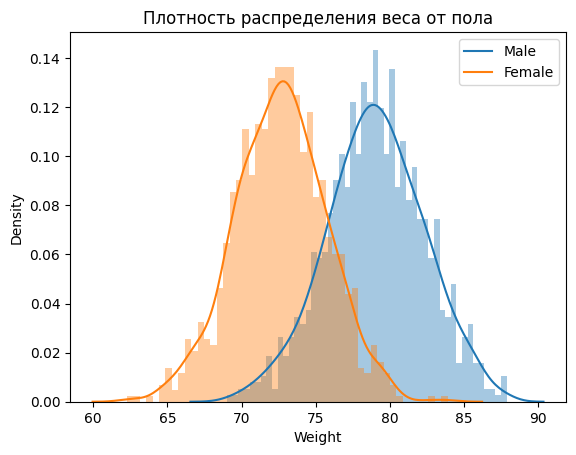

In [ ]:
# Визуализация пересечения интервалов веса мужчин и женщин
# более популярный и удобный вариант с distplot
sns.distplot(df_1['Weight'], 50)
sns.distplot(df_2['Weight'], 50)
plt.title('Плотность распределения веса от пола')
plt.legend(['Male', 'Female'])
plt.show()

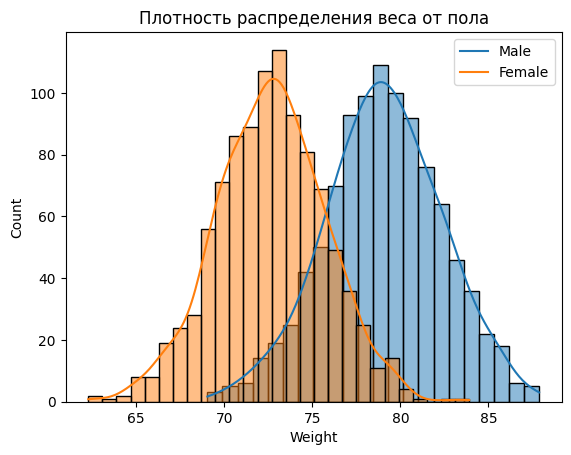

In [ ]:
# актуальная к поддержке в библиотеке альтернатива через histplot
sns.histplot(df_1['Weight'], kde=True)
sns.histplot(df_2['Weight'], kde=True)
plt.title('Плотность распределения веса от пола')
plt.legend(['Male', 'Female'])
plt.show()

Подключения библиотек статистических критериев и задание уровня значимости

In [ ]:
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu

alpha = 0.05                          # Уровень значимости

Проведение Т-Теста (t-критерий Стьюдента)

In [ ]:
result = ttest_ind(df_1['Weight'], df_2['Weight'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


In [ ]:
# Вес мужчин статистически значимо отличается от женщин

Проведение теста Манна — Уитни (U-критерий Манна — Уитни)

In [ ]:
result = mannwhitneyu(df_1['Weight'], df_2['Weight'])
print('p-value: %.8f' % result.pvalue)

if (result.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу')

p-value: 0.00000000
Отвергаем нулевую гипотезу


In [ ]:
# Вес мужчин статистически значимо отличается от женщин